In [4]:
pip install matplotlib networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 1.3 MB/s  0:00:021.3 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


/var/folders/mj/ctj8wtps57d756zwwnpgfqkm0000gn/T/ipykernel_29233/2821890674.py:107: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) Arial Unicode MS.
  plt.tight_layout()
/var/folders/mj/ctj8wtps57d756zwwnpgfqkm0000gn/T/ipykernel_29233/2821890674.py:110: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) Arial Unicode MS.
  plt.savefig("football_experiment_flowchart_final.png", dpi=300, bbox_inches="tight")
/var/folders/mj/ctj8wtps57d756zwwnpgfqkm0000gn/T/ipykernel_29233/2821890674.py:110: UserWarning: Glyph 129489 (\N{ADULT}) missing from font(s) Arial Unicode MS.
  plt.savefig("football_experiment_flowchart_final.png", dpi=300, bbox_inches="tight")
/var/folders/mj/ctj8wtps57d756zwwnpgfqkm0000gn/T/ipykernel_29233/2821890674.py:110: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) Arial Unicode MS.
  plt.savefig("football_experiment_flowchart_final.png", dpi=300, bbox_inches="tight")
/var/folders/mj/ctj8wtps57d756zwwnpgfqkm0000gn/T/ipykernel_292

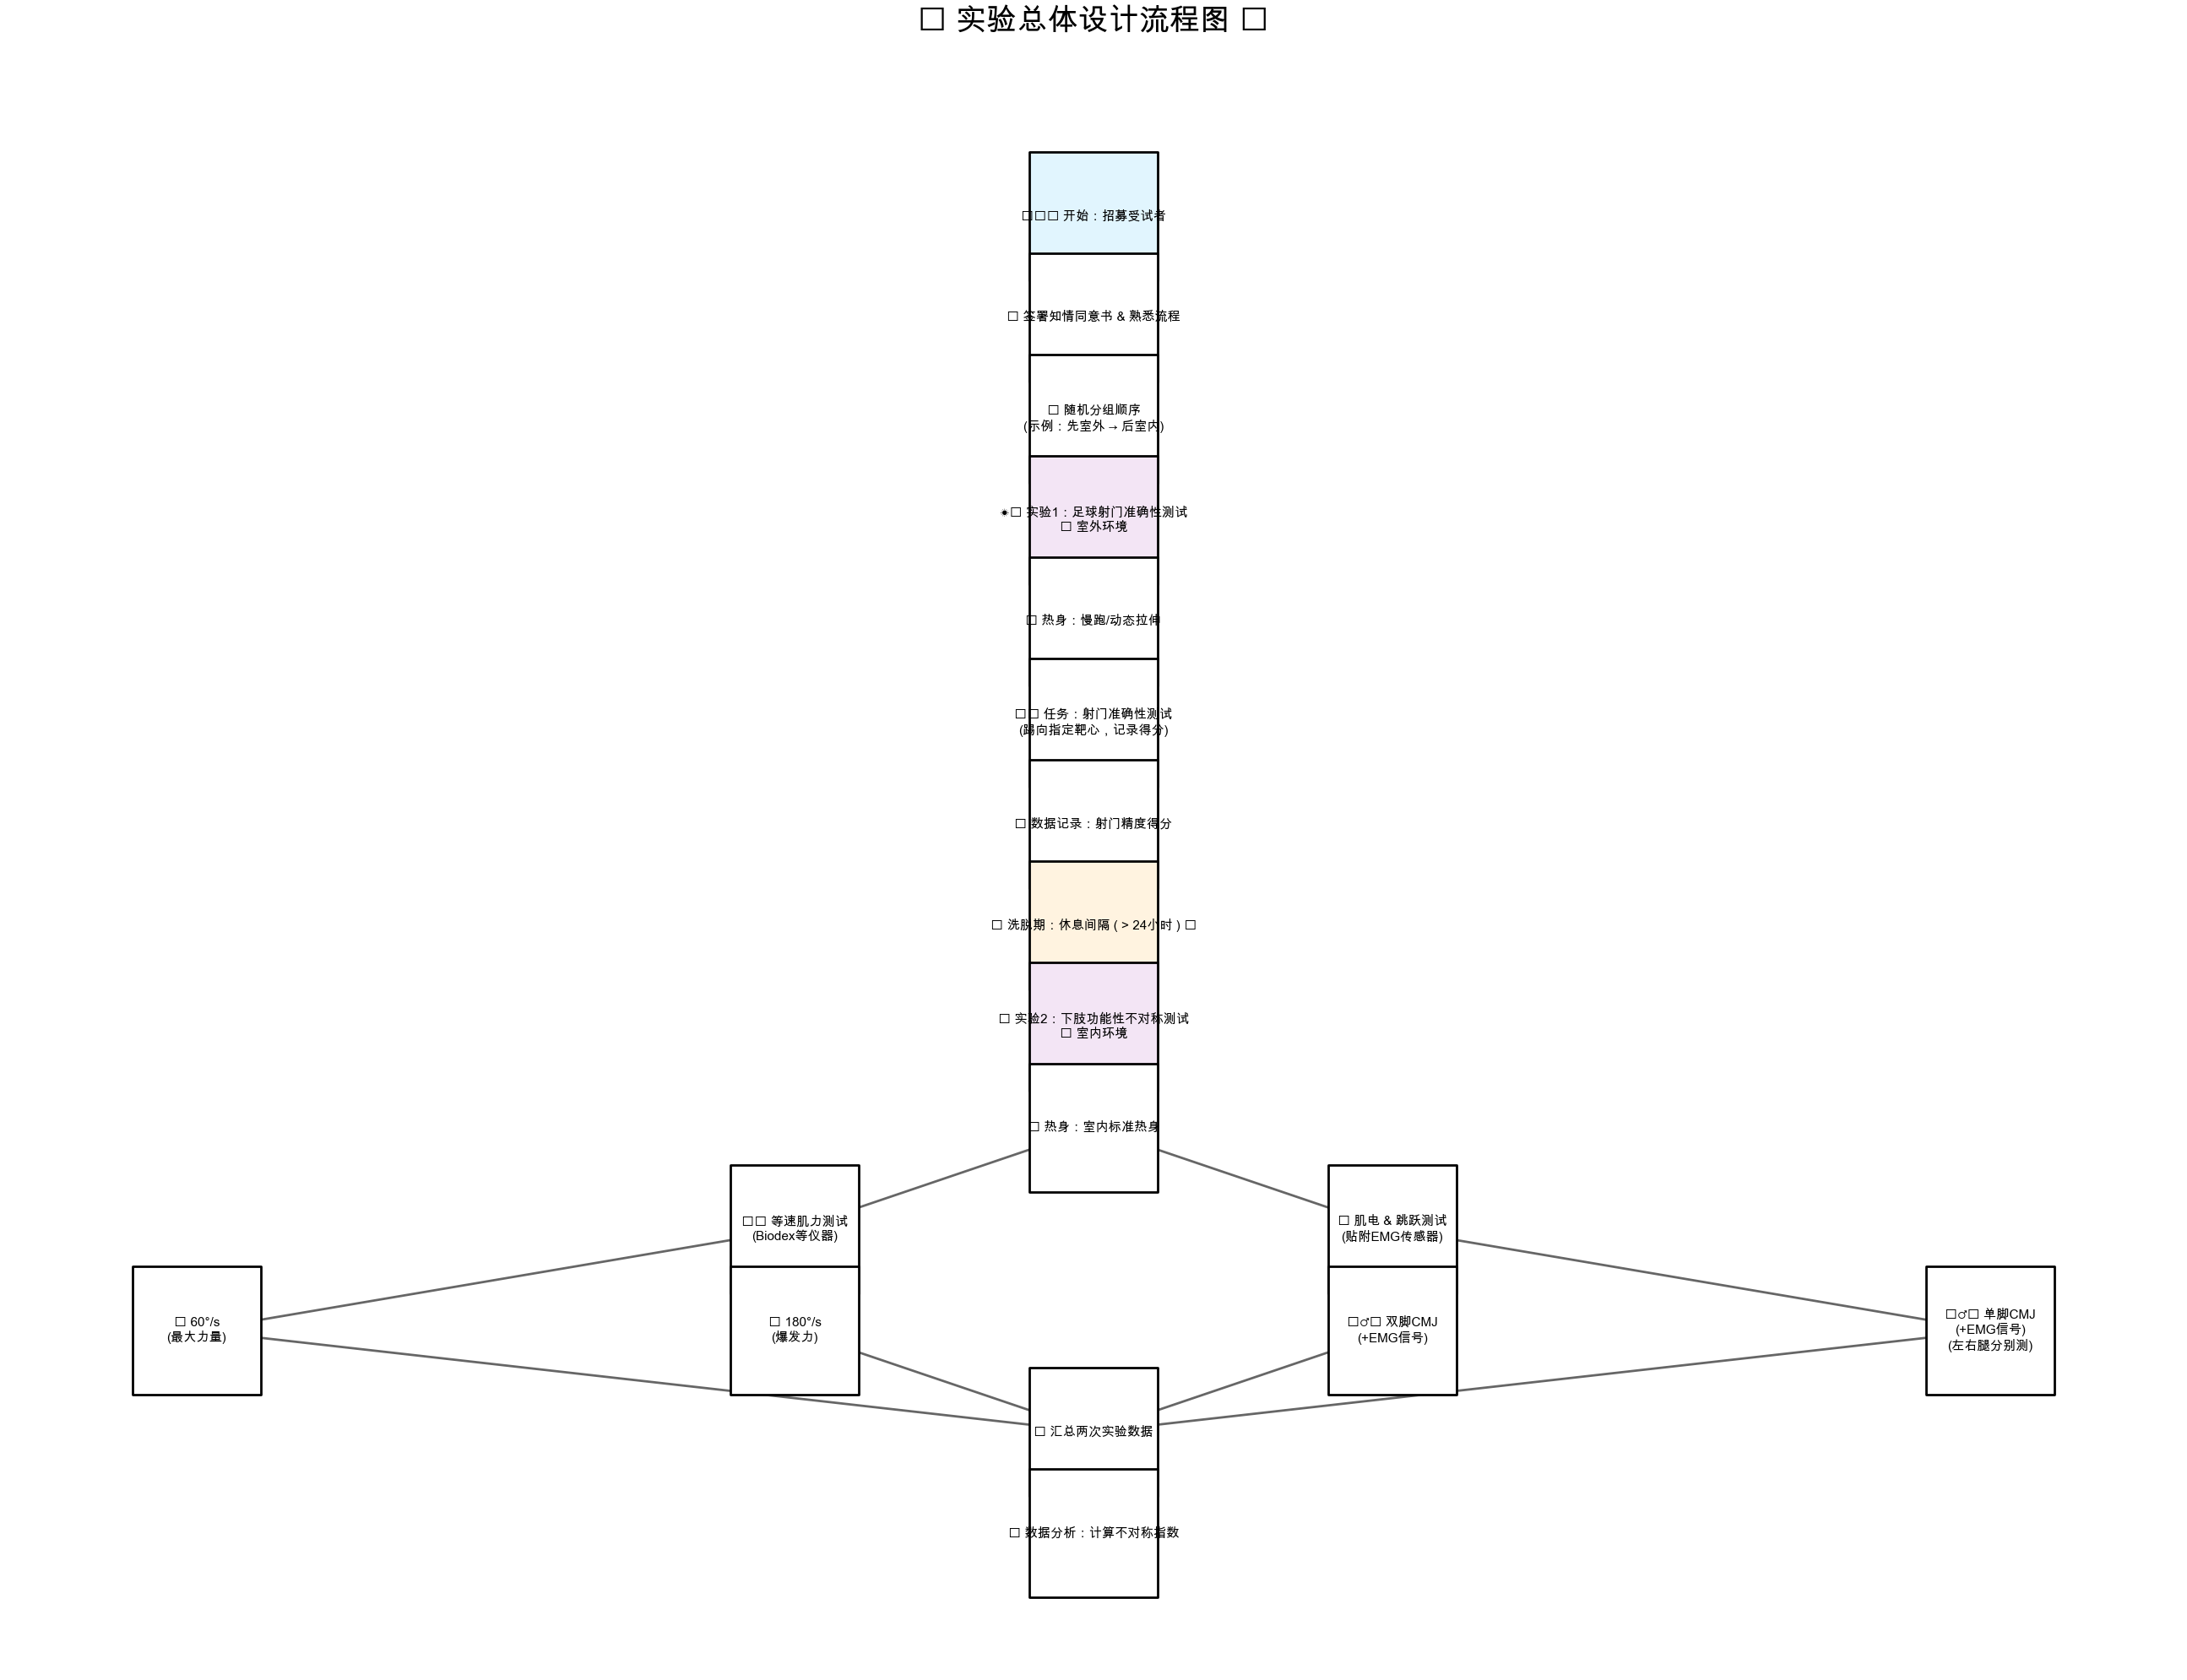

流程图生成成功！文件名为：football_experiment_flowchart_final.png


In [8]:
import matplotlib.pyplot as plt
import networkx as nx

# 设置中文字体（解决中文显示问题，适配多系统）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 创建有向图
G = nx.DiGraph()

# 定义节点和标签
nodes = [
    ("start", "🧑‍🤝‍🧑 开始：招募受试者"),
    ("consent", "📋 签署知情同意书 & 熟悉流程"),
    ("random", "🔀 随机分组顺序\n(示例：先室外 → 后室内)"),
    ("exp1", "☀️ 实验1：足球射门准确性测试\n🌳 室外环境"),
    ("warmup1", "🏃 热身：慢跑/动态拉伸"),
    ("task1", "⚽🥅 任务：射门准确性测试\n(踢向指定靶心，记录得分)"),
    ("record1", "📝 数据记录：射门精度得分"),
    ("washout", "⏰ 洗脱期：休息间隔 ( > 24小时 ) 🛌"),
    ("exp2", "🏠 实验2：下肢功能性不对称测试\n🏢 室内环境"),
    ("warmup2", "🤸 热身：室内标准热身"),
    ("test2_1", "⚙️ 等速肌力测试\n(Biodex等仪器)"),
    ("test2_2", "⚡ 肌电 & 跳跃测试\n(贴附EMG传感器)"),
    ("subtest1_1", "🦵 60°/s\n(最大力量)"),
    ("subtest1_2", "🦵 180°/s\n(爆发力)"),
    ("subtest2_1", "🧘‍♂️ 双脚CMJ\n(+EMG信号)"),
    ("subtest2_2", "🤸‍♂️ 单脚CMJ\n(+EMG信号)\n(左右腿分别测)"),
    ("summary", "📂 汇总两次实验数据"),
    ("analysis", "💻 数据分析：计算不对称指数")
]

# 添加节点
for node_id, label in nodes:
    G.add_node(node_id, label=label)

# 定义边（流程连接关系）
edges = [
    ("start", "consent"), ("consent", "random"), ("random", "exp1"),
    ("exp1", "warmup1"), ("warmup1", "task1"), ("task1", "record1"),
    ("record1", "washout"), ("washout", "exp2"), ("exp2", "warmup2"),
    ("warmup2", "test2_1"), ("warmup2", "test2_2"),
    ("test2_1", "subtest1_1"), ("test2_1", "subtest1_2"),
    ("test2_2", "subtest2_1"), ("test2_2", "subtest2_2"),
    ("subtest1_1", "summary"), ("subtest1_2", "summary"),
    ("subtest2_1", "summary"), ("subtest2_2", "summary"),
    ("summary", "analysis")
]
G.add_edges_from(edges)

# 分层布局（核心：确保流程图从上到下，结构清晰）
layers = {
    0: ["start"], 1: ["consent"], 2: ["random"], 3: ["exp1"],
    4: ["warmup1"], 5: ["task1"], 6: ["record1"], 7: ["washout"],
    8: ["exp2"], 9: ["warmup2"], 10: ["test2_1", "test2_2"],
    11: ["subtest1_1", "subtest1_2", "subtest2_1", "subtest2_2"],
    12: ["summary"], 13: ["analysis"]
}

# 构建位置字典
pos = {}
y_gap = 1.2  # 层间垂直距离
x_gap = 2.5  # 同层水平距离
for layer, nodes_in_layer in layers.items():
    y = -layer * y_gap  # 从上到下排列
    num_nodes = len(nodes_in_layer)
    for i, node in enumerate(nodes_in_layer):
        x = (i - (num_nodes - 1) / 2) * x_gap  # 同层居中
        pos[node] = (x, y)

# 创建画布
fig, ax = plt.subplots(figsize=(26, 20))

# 节点颜色映射
node_color_map = {
    "start": "#E1F5FE", "exp1": "#F3E5F5", "exp2": "#F3E5F5",
    "washout": "#FFF3E0"
}
node_colors = [node_color_map.get(node, "#FFFFFF") for node in G.nodes()]

# 绘制节点（参数全部正确）
nx.draw_networkx_nodes(
    G, pos, ax=ax, node_size=12000, node_color=node_colors,
    node_shape="s", edgecolors="#000000", linewidths=2
)

# 绘制边（已修正 width 参数，无错误）
nx.draw_networkx_edges(
    G, pos, ax=ax, edgelist=edges, arrowstyle="->",
    arrowsize=30, edge_color="#666666", width=2
)

# 绘制标签（✅ 核心修正：移除错误的 ha/va 参数，使用默认居中对齐）
labels = nx.get_node_attributes(G, "label")
nx.draw_networkx_labels(
    G, pos, ax=ax, labels=labels,
    font_size=11, font_weight="normal"
)

# 图表标题
ax.set_title("⚽ 实验总体设计流程图 ⚽", fontsize=26, fontweight="bold", pad=40)

# 隐藏坐标轴
ax.axis("off")

# 调整布局，防止裁剪
plt.tight_layout()

# 保存高清图片
plt.savefig("football_experiment_flowchart_final.png", dpi=300, bbox_inches="tight")

# 显示图片
plt.show()

print("流程图生成成功！文件名为：football_experiment_flowchart_final.png")